# Decomposing a time series into seasonal cycle, trend, and residuals

Many time series contain a cyclical component, long-term trend, and short-term fluctuations. These components are often additive
$$y(t) = T(t) + S(t) + R(t)$$
where $y(t)$ is the observed data, $T(t)$ is the trend component, $S(t)$ is the seasonal or cyclical component, and $R(t)$ are the residuals containing short-term fluctuations. The additive situation will be illustrated below, but the components could also be multiplicative
$$y(t) = T(t) \, S(t) \,  R(t)$$
There are numerous methods for decomposing time series into these components. Selecting an appropriate method requires knowledge of the underlying data and goals of the analysis.

### Parametric and non-parametric methods 

*Parametric* methods make assumptions about the functional form of the seasonal cycle or trend. For example, the trend may be modeled as a linear function or polynomial and the seasonal cycle may be modeled as a sinusoid or sum of sinusoids.

*Non-parametric* methods make no assumption about the functional form of the trend or seasonal cycle. Non-parametric methods for the seasonal or diel cycle include binning data by calendar month or hour of the day, then computing the mean or median of each bin. This may be called a climatology. The trend may be fitted with a smoothing function, such as LOWESS (locally weighted least squares). Frequency filtering can also be used to separate  

### Detrending and deseasonalizing

Detrending an deseasonalizing mean removing one of the components from the time series. 
The detrended time series is
$$y(t) - T(t) = S(t) + R(t)$$
The deseasonalized time series is
$$y(t) - S(t) = T(t) + R(t)$$

### Sample data

This notebook demonstrates some methods to identify and separate the seasonal cycle and trend in a time series. CO2 measurements at Mauna Loa and C2H6 measurements at Utqiagvik (Barrow), Alaska are used as examples.

The CO2 time series exhibits long-term trend, clear seasonal cycle, and other variability. The upward trend has not been constant and the seasonal cycle has increased over decades.

The C2H6 time series has a large seasonal cycle little trend over the years shown here.

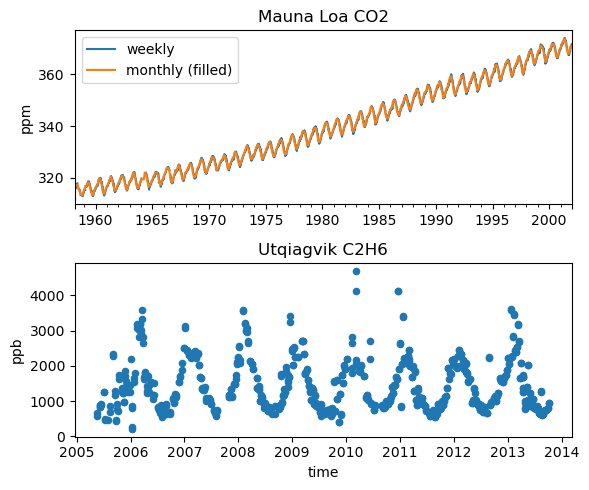

In [1]:
# Imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


import acgc.stats as mystats
from statsmodels.tsa.seasonal import STL, seasonal_decompose

# Load CO2 data
co2 = sm.datasets.co2.load().data.co2
co2_monthly = co2.resample('MS').mean()
co2_monthly_fill = co2_monthly.ffill()

# Load C2H6 data
c2h6 = pd.read_csv('demo/c2h6_brw_surface-flask_1_arl_event.txt', 
                 comment='#', sep=r'\s+',header=None,
                 names=['site_id','year','month','day','hour','minute','second',
                        'sample_id','sample_method','parameter_formula','analysis_group_abbr',
                        'value','uncertainty','analysis_flag',
                        'analysis_instrument','analysis_year','analysis_month','analysis_day','analysis_hour','analysis_minute','analysis_seconds',
                        'latitude','longitude','altitude','event_number'],
                 na_values=-999.99)
c2h6['time'] = pd.to_datetime(c2h6[['year','month','day','hour','minute','second']])

fig, (ax0,ax1) = plt.subplots(2,1, figsize=(6,5))
co2.plot(ax=ax0, label = 'weekly', title='Mauna Loa CO2', ylabel='ppm')
co2_monthly_fill.plot(ax=ax0, label = 'monthly (filled)')
ax0.legend()

c2h6.plot.scatter(x='time',y='value', ax=ax1,title='Utqiagvik C2H6', ylabel='ppb')
fig.tight_layout()
plt.show()


### Time series without trend; binned averages

For a steady time series with little or no trend, $T(t)$ is a constant equal to the mean fo the time series. The simplest way to determine the seasonal component is with binned averages (e.g. using groupby() ). For example, the average of all Januaries, average of all Februaries, etc. This is often called a climatology.

This approach is non-parameteric for the cycle. This method does not require evenly spaced data and missing data are allowed.

An alternate approach would be to fit the time series with sinusoids.

[Text(0, 0.5, 'residuals')]

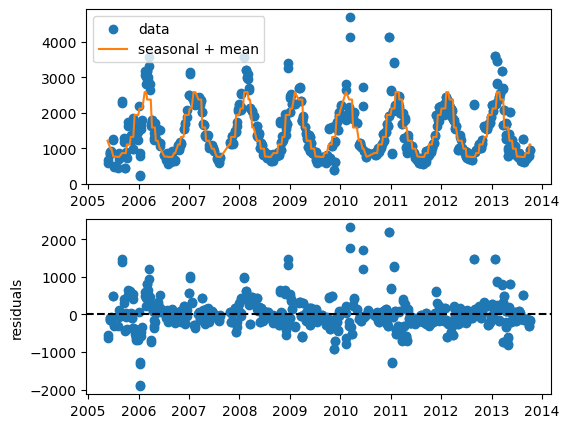

In [2]:
trend = c2h6['value'].mean()
seasonal = (c2h6['value'] - trend).groupby(c2h6.time.dt.month).mean()
residual = c2h6['value'] - trend - seasonal[c2h6.time.dt.month.values].values

fig, (ax0,ax1) = plt.subplots(2,1, figsize=(6,5))
ax0.scatter('time', 'value', data=c2h6, label='data')
ax0.plot(c2h6.time,trend + seasonal[c2h6.time.dt.month.values], 
         label='seasonal + mean',
         color='C1')
ax0.legend()

ax1.scatter(c2h6.time, residual, label='residual')
ax1.axhline(y=0, color='k', ls='--')
ax1.set(ylabel='residuals')

### `seasonal_decompose`

This method in statsmodels is non-parametric for the trend and cycle. It requires evenly spaced data with no missing values. A boxcar filter with length equal to the period is used to separate the trend component. The cyclical component is determined by the grouped mean of detrended data. For example, the average of all Januaries. The result is a fixed seasonal cycle. 

More sophisticated methods may be preferable.

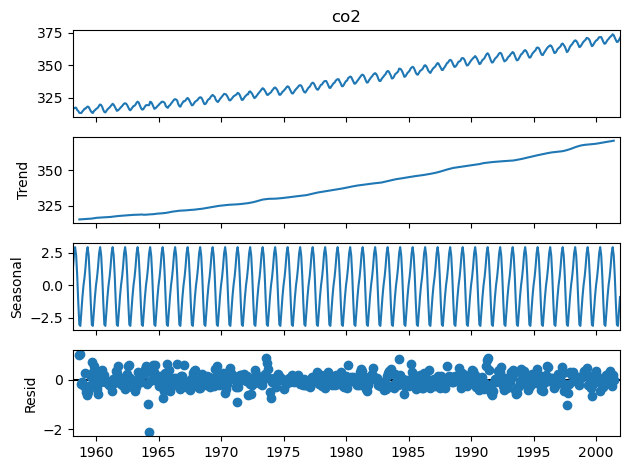

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

result_sd = seasonal_decompose(co2_monthly_fill, model='additive', period=12)
fig = result_sd.plot()

### Seasonal-Trend decomposisiont with LOESS `STL`

This method is non-parametric for trend and cycle components. It requires evenly spaced data without gaps. The cyclic component is not fixed in STL, but is allowed to vary slowly in this decomposition.

`STL` has many additional parameters described in the statsmodels documentation. 

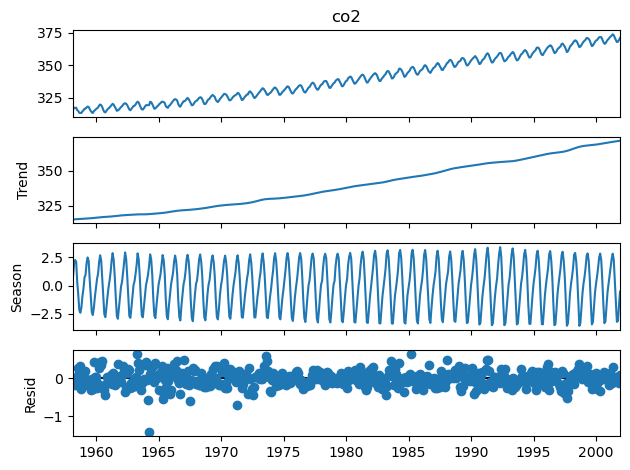

In [4]:
from statsmodels.tsa.seasonal import STL

result = STL(co2_monthly_fill, period=12).fit()
fig = result.plot()

### STL with smoother seasonal cycle

Seasonal cycles are often (but not always) expected to vary smoothly if they are sample at a frequency much higher than the seasonal cycle. For example, if the annual cycle of temperature is estimated from daily data, we expect the smooth variations across sequential days in the average cycle. STL can produce irregular seasonal cycles under these conditions, because the cycle value on Jan 1 is constructed separately from the cycle value for Jan 2, etc. `acgc.stats` provides 2 functions to address this limitation. 

### `STL_smoother`

`STL_smoother` applies additional smoothing to the seasonal cycle produced by STL.


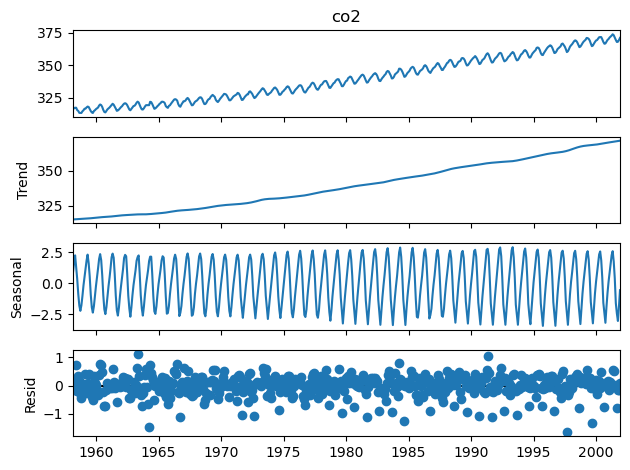

In [5]:
import acgc.stats as mystats

result = mystats.STL_smoother(co2_monthly_fill, period=12, smooth=4)
fig = result.plot()

### `STL_harmonic`

`STL_harmonic` is a variation on the STL approach. The trend is fitted with LOWESS like STL, while the seasonal cycle is constructed from a sinusoid and its harmonics. This results in a smooth seasonal cycle, unless the number of harmonics is very hight. The resulting seasonal cycle is fixed, unlike STL. This method is non-parametric for the trend, but parametric for the cyclic component. Irregularly spaced data are allowed, but missing data are not.

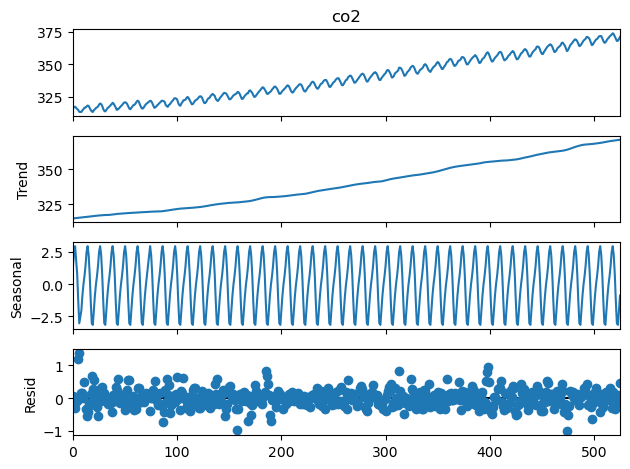

In [6]:
import acgc.stats as mystats

# Several ways to call STL_harmonic are shown. All produce the sane result.

# Passing y and x explicitly.
# Since x is a datetime index, the period should be a timedelta
result = mystats.STL_harmonic(co2_monthly.dropna(), co2_monthly.dropna().index,
                              period=pd.Timedelta(days=365.25))

# Passing x implicitly; STL_harmonic uses the index of a pandas Series if x is not provided
result = mystats.STL_harmonic(co2_monthly.dropna(), 
                              period=pd.Timedelta(days=365.25))

# Resetting the index to simple integer range (values will be treated as equally spaced, slightly less accurate than above)
# If x is not datetime-like, the period should be an integer or float
result = mystats.STL_harmonic(co2_monthly.reset_index(drop=True).dropna(), 
                              period=12)


fig = result.plot()